# Adversarial NLI Robustness with Curriculum Training

### Course: Machine Learning
### Student: Rajashree Mohan Devale, Turuvekere Satish Sagar
### Matriculation Number: 80785727, 26400540
### Group Number: ML_DS_90_09

---

**Objective**

Investigate whether curriculum learning improves the robustness of compact Natural Language Inference (NLI) models on adversarial examples while maintaining standard accuracy.

# 📌 Problem Statement

---

### **Models that score well on standard NLI benchmarks (SNLI, MultiNLI) fail badly on adversarially collected examples; compact models, which are the ones actually deployed under latency/memory constraints, fail hardest.**

---

### **ANLI was collected in three rounds (R1, R2, R3), each written to fool a stronger model — so the rounds form a built-in easy → hard difficulty ladder.**

---

## 🎯 Core Question

> **Does training compact transformers on ANLI rounds in order of difficulty (Curriculum: R1 → R2 → R3) beat standard training on all rounds mixed and shuffled, at the same training budget?**

---

## ❓ Sub-Questions

**1.** How does accuracy on each test round evolve as the curriculum advances?

**2.** Does training order affect calibration, i.e., how often the model is confidently wrong?

---

# 📂 Dataset

---

### **Source**
- Adversarial NLI (ANLI), official splits from the ANLI release (**Nie et al., ACL 2020**); loaded from **JSONL** files *(train/dev/test per round).*

---

### **Task / Labels**
- **3-way sentence-pair classification**
  - **Entailment** *(e → 0)*
  - **Neutral** *(n → 1)*
  - **Contradiction** *(c → 2)*

---

### **Fields Used**
- **Premise**
- **Hypothesis**
- **Gold Label**

Sentence pairs are concatenated using the model's **separator token** and truncated to **128 tokens**.

---

### **Sample Example**

**Premise:** A short factual passage *(e.g., from Wikipedia).*

**Hypothesis:** An annotator-written claim designed to fool the target model.

**Label:** **e / n / c**

---

### **Dataset Size**

- **Train:** 162,865
- **Development:** 3,200
- **Test:** 3,200

> **No subsetting — all rounds used in full.**

---

## 📊 Table 1. ANLI Statistics per Round

| **Round** | **Train** | **Dev** | **Test** |
|:---------:|----------:|---------:|----------:|
| **R1** | 16,946 | 1,000 | 1,000 |
| **R2** | 45,460 | 1,000 | 1,000 |
| **R3** | 100,459 | 1,200 | 1,200 |
| **Total** | **162,865** | **3,200** | **3,200** |

---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import copy
import json

import numpy as np
import torch
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AlbertForSequenceClassification,
    AlbertTokenizer,
    get_linear_schedule_with_warmup,
)

from sklearn.metrics import f1_score

from tqdm.auto import tqdm

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
LABEL2ID = {"e": 0, "n": 1, "c": 2}
BASE     = "drive/MyDrive/anli/"

def load_jsonl(filepath):
    with open(filepath) as f:
        return [json.loads(l) for l in open(filepath) if l.strip()]

class ANLIDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        row = self.data[idx]
        enc = tokenizer(row["context"], row["hypothesis"],
                        max_length=128, truncation=True,
                        padding="max_length", return_tensors="pt")
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(LABEL2ID[row["label"]], dtype=torch.long)
        }

r1_data = load_jsonl(BASE + "R1/" + "train.jsonl")
r2_data = load_jsonl(BASE + "R2/" + "train.jsonl")
r3_data = load_jsonl(BASE + "R3/" + "train.jsonl")
r1_dev  = load_jsonl(BASE + "R1/" + "dev.jsonl")
r2_dev  = load_jsonl(BASE + "R2/" + "dev.jsonl")
r3_dev  = load_jsonl(BASE + "R3/" + "dev.jsonl")

print("R1:", len(r1_data), "| R2:", len(r2_data), "| R3:", len(r3_data))

R1: 16946 | R2: 45460 | R3: 100459


# ⚙️ Methodology

---

### **Preprocessing**
- JSONL parsing
- Label mapping **{e, n, c} → {0, 1, 2}**
- `tokenizer(premise, hypothesis)` with **padding/truncation to 128 tokens**
- PyTorch **Dataset** / **DataLoader** *(batch size = 32)*

---

### **Split Design**
- Official ANLI round splits kept intact.
- Each round has its own **development** and **test** set.
- Performance is always reported separately for:
  - **R1 Test**
  - **R2 Test**
  - **R3 Test**

---

### **Curriculum Workflow**
- **Three phases** in round order.
- **Phase k**
  - Fine-tune **3 epochs** on **Rk train** only.
  - Validate on **Rk dev** after each epoch.
  - Restore the **best-dev checkpoint** before starting **Phase k + 1**.
- The model exiting **Phase 3** is the **final curriculum model**.

---

### **Baseline Workflow**
- Identical training recipe.
- All **162,865** training examples concatenated and shuffled.
- **3 epochs** of training.
- Validated on the **pooled dev** sets.
- Best checkpoint retained.

> **Both regimes make 3 passes over every example → budget-matched comparison.**

---

### **Validation**
- Best-checkpoint selection performed **only on the development sets**.
- Test sets are **touched once**, during the final evaluation.

---

### **Analysis**
- Per-round test metrics
- Stage-wise checkpoint evaluation
- High-confidence error counts
- Confusion matrices

---

# 🤖 Selected Models

---

### **DistilBERT-base-uncased**
- **6 layers**
- **66M parameters**
- Distilled BERT retaining most GLUE performance at **40% of the size**.
- Used as a **standard efficiency baseline**.

---

### **ALBERT-base-v2**
- **12 layers** with **cross-layer parameter sharing**
- **12M parameters**
- Tests whether findings hold for a **differently-compressed architecture**.

---

### **Why These Models?**
- Both are **compact transformer encoders** commonly used in real-world deployments.
- Their limited capacity makes them plausibly **sensitive to training order**, which is the primary variable under study.
- Each model is initialized with a **fresh 3-way classification head**.

---

### **Baseline Model**
- The **same backbone architecture** trained on **mixed and shuffled data**.
- Ensures **training order** is the **only experimental difference**.

---

### **Optimization Settings**

| **Parameter** | **Value** |
|--------------|-----------|
| Optimizer | AdamW |
| Learning Rate | 2 × 10⁻⁵ |
| Weight Decay | 0.01 |
| Batch Size | 32 |
| Learning Rate Scheduler | Linear schedule with warmup |
| Hardware | Single NVIDIA A100 GPU (Google Colab) |

---

# 📈 Evaluation Criterion

---

### **Accuracy per Test Round**
- Main headline metric.
- Reported separately for:
  - **R1**
  - **R2**
  - **R3**
- Difficulty differs across rounds, so separate evaluation is essential.

---

### **Per-Class F1 Score**
- Evaluated for each class:
  - **Entailment**
  - **Neutral**
  - **Contradiction**
- ANLI classes behave very differently.
- Accuracy alone hides that **contradiction** is typically the weakest-performing class.

---

### **Test Loss (Cross-Entropy)**
- Measures the confidence of predictions, not just correctness.
- Complements accuracy by providing additional insight into model behavior.

---

### **High-Confidence Errors (Task-Specific)**
- Counts incorrect test predictions with **Softmax confidence > τ**.
- **Headline threshold:** τ = **0.9**
- **Additional sweep:** τ = **0.6 – 0.9**

> On an adversarial benchmark, **being confidently wrong is the most dangerous failure mode**, making this an effective practical measure of model calibration.

---

In [4]:
def evaluate(model, data, device):
    model.eval()

    loader = DataLoader(
        ANLIDataset(data),
        batch_size=32,
        shuffle=False
    )

    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            preds = outputs.logits.argmax(dim=-1)

            total_loss += outputs.loss.item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_labels))

    f1 = f1_score(
        all_labels,
        all_preds,
        average=None,
        labels=[0, 1, 2]
    )

    avg_loss = total_loss / len(loader)

    return avg_loss, acc, f1

# 📊 Results

---

### **Training Dynamics**
- Dev accuracy improves within every round and steps up across rounds for both models (**Figure 1**).
- **ALBERT** stays above **DistilBERT** throughout.

> **Figure 1.** Dev accuracy per epoch during curriculum training *(vertical lines = round transitions; each round validated on its own dev split).*

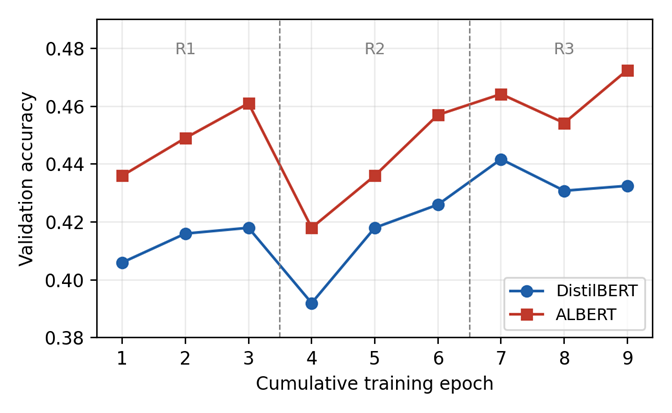
---

### **DistilBERT**
- Curriculum ≈ mixed on **R1/R2** *(−0.6 / −0.1 points)*.
- Clearly better on the hardest round **R3**:
  - **44.83% vs 42.00% (+2.83)**
  - Lower test loss (**1.2678 vs 1.3445**)

#### **Table 2. DistilBERT Test Results — Curriculum vs Mixed Baseline**

| Model | Test | Loss | Acc. | F1 ent | F1 neu | F1 con |
|------|:---:|----:|----:|----:|----:|----:|
| Curriculum | R1 | 1.1129 | .5160 | .5463 | .5609 | .4157 |
| | R2 | 1.3715 | .4110 | .4714 | .4274 | .2907 |
| | R3 | 1.2678 | .4483 | .4968 | .4476 | .3844 |
| Mixed | R1 | 1.1004 | .5220 | .5222 | .5728 | .4660 |
| | R2 | 1.3606 | .4120 | .4673 | .4219 | .3238 |
| | R3 | 1.3445 | .4200 | .4197 | .4560 | .3821 |

---

### **ALBERT — Stage-wise Performance**
- Accuracy on every test round rises **monotonically** as the curriculum advances (**Table 3**).
- Harder rounds improve earlier rounds too → **No catastrophic forgetting**.

#### **Table 3. ALBERT Test Accuracy per Curriculum Stage vs Mixed Baseline**

| Model | R1 Test | R2 Test | R3 Test |
|------|--------:|--------:|--------:|
| After R1 Phase | .4330 | .3460 | .3367 |
| After R2 Phase | .4950 | .4010 | .3767 |
| After R3 Phase | .5060 | .4190 | .4200 |
| Curriculum (Final) | .5550 | .4360 | .4617 |
| Mixed Baseline | .5580 | .4390 | .4475 |

---

### **ALBERT — Final Results**
- Mixed marginally ahead on:
  - **R1:** 55.80 vs 55.50
  - **R2:** 43.90 vs 43.60
- Curriculum wins on **R3**:
  - **46.17 vs 44.75 (+1.42)**
- Lower test loss on all rounds *(e.g., 1.0458 vs 1.0861 on R1).*

#### **Table 4. Per-Class F1 of the Final ALBERT Models**

| Model | Test | Loss | Acc. | F1 ent | F1 neu | F1 con |
|------|:---:|----:|----:|----:|----:|----:|
| Curriculum | R1 | 1.0458 | .5550 | .5725 | .6119 | .4618 |
| | R2 | 1.3227 | .4360 | .4901 | .4601 | .3279 |
| | R3 | 1.2879 | .4617 | .5011 | .4971 | .3671 |
| Mixed | R1 | 1.0861 | .5580 | .5674 | .6047 | .4940 |
| | R2 | 1.3830 | .4390 | .4821 | .4587 | .3592 |
| | R3 | 1.3542 | .4475 | .4778 | .4686 | .3891 |

---

### **Takeaway vs Baseline**
- Curriculum ≈ mixed on **easy rounds**.
- Consistently better on the **hardest round** for both architectures.
- Better calibrated *(see Error Analysis).*

---

# 🔍 Error Analysis and Limitations

---

### **High-Confidence Errors (τ = 0.9)**
- Curriculum **DistilBERT** is confidently wrong less often than mixed on every round:
  - **R1:** 30 vs 39
  - **R2:** 76 vs 91
  - **R3:** 62 vs 89 *(30% relative reduction)*
- **ALBERT Curriculum:** 49 / 79 / 89

#### **Table 5. Wrong Predictions with Confidence > 0.9**

| Model | R1 | R2 | R3 |
|------|---:|---:|---:|
| DistilBERT Curriculum | 30 | 76 | 62 |
| DistilBERT Mixed | 39 | 91 | 89 |
| ALBERT Curriculum | 49 | 79 | 89 |

> *(R1/R2: 1,000 examples • R3: 1,200 examples)*

---

### **Threshold Sweep (ALBERT Curriculum)**
- Errors increase rapidly as **τ** is relaxed:
  - **0.9:** 49 / 79 / 89
  - **0.6:** 282 / 392 / 428
- Even the better-calibrated model is **confident-and-wrong** on approximately **28–36%** of test examples at **τ = 0.6**.

---

### **Dominant Failure Case**
- True **contradictions** predicted as **entailment**.
- **148** for curriculum vs **135** for mixed on **R1** *(Figure 2).*
- **Contradiction** has the **lowest F1** for every model on every round.

> **Figure 2.** Confusion matrices on R1 test — final ALBERT curriculum model *(left)* vs mixed baseline *(right).*
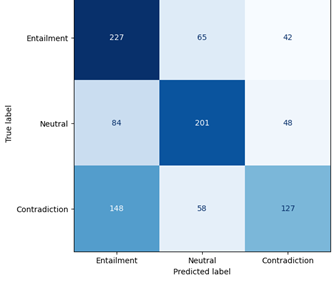  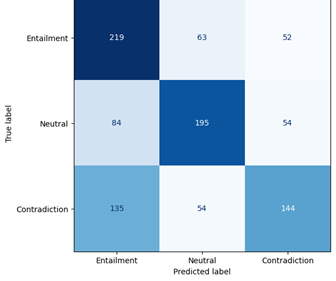
---

## ⚠️ Limitations

- **Single Seed**
  - One run per configuration.
  - R1/R2 gaps *(≤ 0.6 points)* are within plausible seed noise.
  - Multi-seed replication is needed before making strong claims.

- **Coarse Difficulty**
  - Round index is the only difficulty signal.
  - Within-round ordering *(e.g., competence-based)* remains untested.

- **Model Scale**
  - Only base-size models were evaluated.
  - It is unknown whether the same effect persists for larger backbones or anti-curriculum ordering.

---

## 🚀 Improvement Ideas

- Multi-seed averaging.
- Length- or loss-based within-round curricula.
- Replay earlier rounds during Phase 3.
- Calibration methods *(e.g., temperature scaling)* on top of curriculum training.

---

# ✅ Conclusion

---

### **Answer to the Project Question**
- **Yes, with a caveat.**
- At a **matched training budget**, the **round-ordered curriculum**:
  - Matches mixed training on the **easier rounds**.
  - Outperforms mixed training on the **hardest round**:
    - **DistilBERT:** **+2.83** accuracy points on **R3**
    - **ALBERT:** **+1.42** accuracy points on **R3**

---

### **Model Calibration**
- Curriculum-trained models are **better calibrated**.
- Observed through:
  - **Fewer high-confidence errors** on every round *(DistilBERT)*.
  - **Lower test loss** on every round *(both models).*

---

### **Key Finding**
- ANLI's **round structure** provides a **free curriculum signal**.
- No additional:
  - Data
  - Compute
  - Difficulty estimation

are required.

---

### **Final Observation**
- Absolute accuracy (**42–56%**) remains **well below human performance**.
- The contribution of this work is identifying a **better training strategy**, **not** demonstrating deployment-ready performance.

---